In [3]:
%reload_kedro

# Load yield and metrics data
yield_data = catalog.load("yield_spreadsheet")
metric_data = catalog.load("human_readable_metrics", version="2025-05-05T13.40.31.083Z")

2026-01-22 09:54:00,479 - kedro.ipython - INFO - Resolved project path as: /home/daniel/git/aerial_flower_counting.
To set a different path, run '%reload_kedro <project_root>'
2026-01-22 09:54:00,610 - py.warnings - WARNING - /home/daniel/git/aerial_flower_counting/.venv/lib/python3.10/site-packages/kedro/framework/session/session.py:267: KedroDeprecationWarning: TemplatedConfigLoader will be deprecated in Kedro 0.19. Please use the OmegaConfigLoader instead. To consult the documentation for OmegaConfigLoader, see here: https://docs.kedro.org/en/stable/configuration/advanced_configuration.html#omegaconfigloader
  warnings.warn(

2026-01-22 09:54:00,645 - py.warnings - WARNING - /home/daniel/git/aerial_flower_counting/.venv/lib/python3.10/site-packages/kedro/io/partitioned_dataset.py:200: KedroDeprecationWarning: 'PartitionedDataset' has been moved to `kedro-datasets` and will be removed in Kedro 0.19.0.
  warnings.warn(

2026-01-22 09:54:00,652 - py.warnings - WARNING - /home/daniel/gi

In [7]:
import pandas as pd

yield_data_min = yield_data[["TREATMENT", "Lint_Pc", "lint_yld"]]
metrics_with_yield = pd.merge(yield_data_min, metric_data, left_on="TREATMENT", right_on="Genotype")
metrics_with_yield

,TREATMENT,Lint_Pc,lint_yld,Genotype,Peak DAP,plot_num_peak,Peak Count,Start DAP,plot_num_start,Start Count,...,Slope (flowers/day),Intercept,Last Effective Flower Count,Last Effective Flower %,Total Count,Start Outlier,End Outlier,Duration Outlier,Peak Outlier,Slope Outlier
0,F4 2022 433,43.169399,985.768656,F4 2022 433,94.333333,1340.000000,245.333333,65.666667,1340.000000,9.333333,...,7.982137,-544.790339,361.333333,93.765834,381.666667,0,0,0,0,0
1,F4 2022 433,44.613351,960.549346,F4 2022 433,94.333333,1340.000000,245.333333,65.666667,1340.000000,9.333333,...,7.982137,-544.790339,361.333333,93.765834,381.666667,0,0,0,0,0
2,F4 2022 433,43.944408,1489.782848,F4 2022 433,94.333333,1340.000000,245.333333,65.666667,1340.000000,9.333333,...,7.982137,-544.790339,361.333333,93.765834,381.666667,0,0,0,0,0
3,F4 2022 459,43.475366,1294.371777,F4 2022 459,87.666667,1420.666667,157.333333,72.000000,1420.666667,13.000000,...,8.936980,-646.138551,341.666667,92.970590,366.000000,0,0,0,0,0
4,F4 2022 459,43.366619,1397.756614,F4 2022 459,87.666667,1420.666667,157.333333,72.000000,1420.666667,13.000000,...,8.936980,-646.138551,341.666667,92.970590,366.000000,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,F4 2022 480,46.217228,1581.296490,F4 2022 480,83.666667,1487.000000,205.333333,65.666667,1487.000000,11.333333,...,9.712662,-661.904676,418.000000,92.994090,444.333333,0,0,0,0,0
408,F4 2022 480,46.020067,1272.006823,F4 2022 480,83.666667,1487.000000,205.333333,65.666667,1487.000000,11.333333,...,9.712662,-661.904676,418.000000,92.994090,444.333333,0,0,0,0,0
409,F4 2022 251,43.122677,1396.570091,F4 2022 251,93.500000,1462.000000,276.000000,72.500000,1462.000000,17.500000,...,12.359888,-923.835670,419.000000,87.242204,463.500000,0,0,0,0,0
410,F4 2022 251,44.982935,1792.107344,F4 2022 251,93.500000,1462.000000,276.000000,72.500000,1462.000000,17.500000,...,12.359888,-923.835670,419.000000,87.242204,463.500000,0,0,0,0,0


In [9]:
metrics_with_yield.columns


Index(['TREATMENT', 'Lint_Pc', 'lint_yld', 'Genotype', 'Peak DAP',
       'plot_num_peak', 'Peak Count', 'Start DAP', 'plot_num_start',
       'Start Count', 'End DAP', 'plot_num', 'End Count', 'Duration (days)',
       'Slope (flowers/day)', 'Intercept', 'Last Effective Flower Count',
       'Last Effective Flower %', 'Total Count', 'Start Outlier',
       'End Outlier', 'Duration Outlier', 'Peak Outlier', 'Slope Outlier'],
      dtype='object')

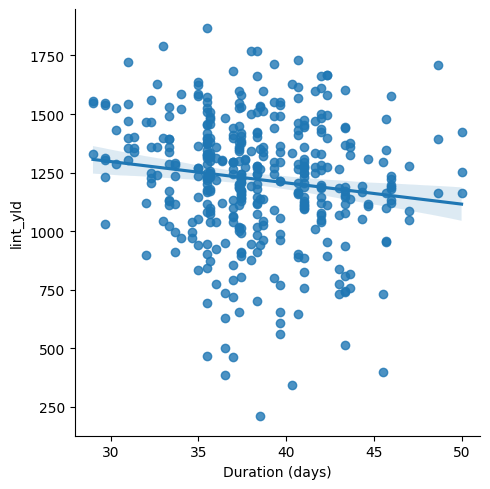

In [10]:
import seaborn

seaborn.lmplot(metrics_with_yield, x="Duration (days)", y="lint_yld")

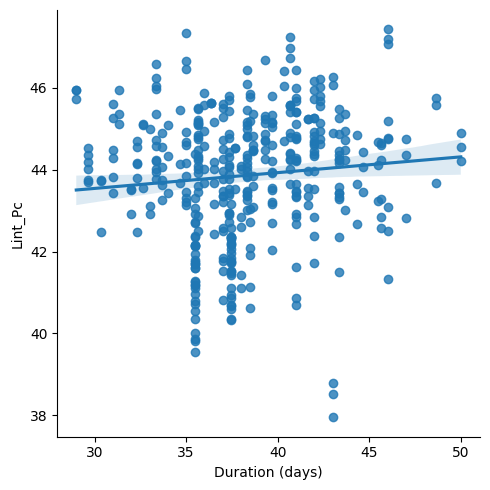

In [11]:
import seaborn

seaborn.lmplot(metrics_with_yield, x="Duration (days)", y="Lint_Pc")

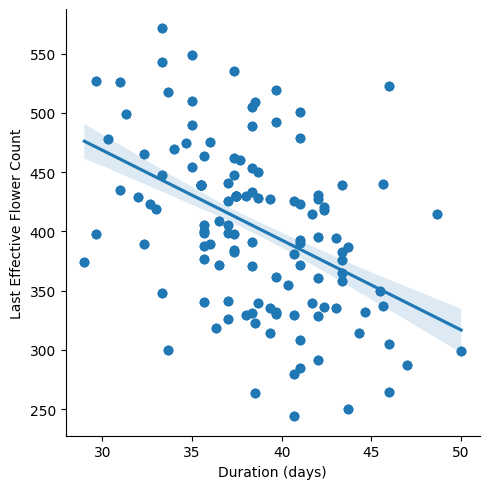

In [12]:
import seaborn

seaborn.lmplot(metrics_with_yield, x="Duration (days)", y="Last Effective Flower Count")

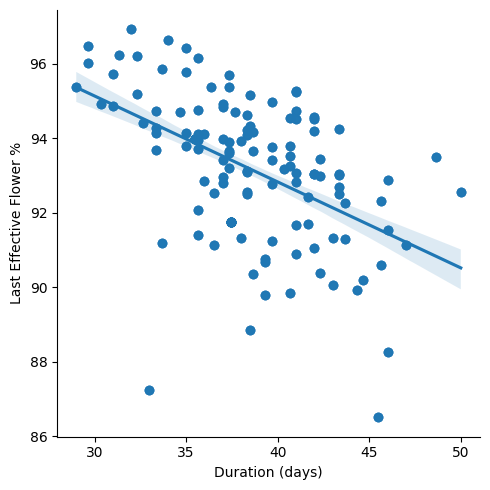

In [14]:
import seaborn

seaborn.lmplot(metrics_with_yield, x="Duration (days)", y="Last Effective Flower %")

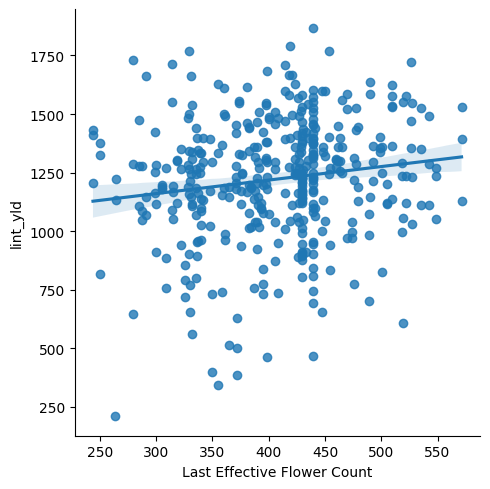

In [13]:
import seaborn

seaborn.lmplot(metrics_with_yield, x="Last Effective Flower Count", y="lint_yld")